# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**

## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

# Introduction 
The product team has contacted us and aksed for a model that predicts whcich recipes will be popular witha a precision of 80% of the times. They provided a dataset with 8 variables and 947 observations. As our main objective is to classify if the recipes will have high or low traffic we first will analyze the database, validate the information and prepare for the model. 

Objective:

- Predict which recipes will lead to high traffic
- Predict correctly 80% of the time

In [144]:
# Packages Required for this Certification
install.packages("randomForest")
install.packages("naniar")
install.packages("ggprism")
install.packages("ggpubr")
install.packages("ggplot2")
install.packages("pROC")
install.packages("MLmetrics")
install.packages("gbm")

The following package(s) will be installed:
- randomForest [4.7-1.2]
These packages will be installed into "~/renv/library/R-4.2/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing randomForest ...                   OK [linked from cache]
The following package(s) will be installed:
- naniar [1.1.0]
These packages will be installed into "~/renv/library/R-4.2/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing naniar ...                         OK [linked from cache]
The following package(s) will be installed:
- ggprism [1.0.7]
These packages will be installed into "~/renv/library/R-4.2/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing ggprism ...                        OK [linked from cache]
The following package(s) will be installed:
- ggpubr [0.6.2]
These packages will be installed into "~/renv/li

In [145]:
# Load libraries
library(tidyverse)
library(randomForest)
library(tidymodels)
library(naniar)
library(class)
library(caret)
library(patchwork)
library(ggprism)
library(skimr)
library(janitor)
library(car)
library(ggpubr)
library(pROC)
library(MLmetrics)
library(gbm)

# Database Structure

Our database is a csv file with 8 columns (variables) and 947 rows (observations). Accordingly with the information provided the 8 variables are the following: 
1. Recipe: Unique identifier of recipe (Integer)
2. Calories: Number of calories, in grams (Numeric, Cont.)
3. Carbohydrate: Amount of Carbohydrates in grams (Numeric, Cont.)
4. Sugar: Amount of Suger in grams (Numeric, Cont.)
5. Protein: Amount of protein in grams (Numeric, Cont.)
6. Category: Type of recipes, ten possible groups (Categorical)
7. Sevings: Number of Servings for Recipe (Integer)
8. High Traffic: Conditional value when the traffic of the site was high when the recipe was shown (Logical, 0, 1).

As we show in the following steps. Some modifications and adjustments were made (see below) to fit all the variables into the correct class of the dataset. 

In [146]:
#Structure of the dataset provided by the team

traffic_site <- read_csv("recipe_site_traffic_2212.csv")

glimpse(traffic_site)

Rows: 947 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): recipe, category, servings, high_traffic
dbl (4): calories, carbohydrate, sugar, protein

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 947
Columns: 8
$ recipe       <chr> "001", "002", "003", "004", "005", "006", "007", "008", "…
$ calories     <dbl> NA, 35.48, 914.28, 97.03, 27.05, 691.15, 183.94, 299.14, …
$ carbohydrate <dbl> NA, 38.56, 42.68, 30.56, 1.85, 3.46, 47.95, 3.17, 3.78, 4…
$ sugar        <dbl> NA, 0.66, 3.09, 38.63, 0.80, 1.65, 9.75, 0.40, 3.37, 3.99…
$ protein      <dbl> NA, 0.92, 2.88, 0.02, 0.53, 53.93, 46.71, 32.40, 3.79, 11…
$ category     <chr> "Pork", "Potato", "Breakfast", "Beverages", "Beverages", …
$ servings     <chr> "6", "4", "1", "4", "4", "2", "4", "4", "6", "2", "1", "6…
$ high_traffic <chr> "High", "High", NA, "High", NA, "High", NA, NA, "High", N…


# 1. Data Validation 
We first reviewed the database with summary functions, to identify the structure and the missing values that could be presernt. We identifed 52 records with missing values, this is about 5.5% of the all database. Using a visualization tool (vis_miss()) we identified non-random missing (systematic missingness) values in the numerical variables (calories, carbohydrate, sugar and protein). See the left plot.

As a point of good practice, we decided to do not include this **52 records** in the next steps of the analysis, because the non-randomness nature of the missing values. Using filter() we eliminated the NA values and confirmed it with functions and visualization. See right-plot.

Whith this we can prepare our database for more complex analysis. 

    recipe             calories        carbohydrate         sugar        
 Length:947         Min.   :   0.14   Min.   :  0.030   Min.   :  0.010  
 Class :character   1st Qu.: 110.43   1st Qu.:  8.375   1st Qu.:  1.690  
 Mode  :character   Median : 288.55   Median : 21.480   Median :  4.550  
                    Mean   : 435.94   Mean   : 35.070   Mean   :  9.047  
                    3rd Qu.: 597.65   3rd Qu.: 44.965   3rd Qu.:  9.800  
                    Max.   :3633.16   Max.   :530.420   Max.   :148.750  
                    NA's   :52        NA's   :52        NA's   :52       
    protein          category           servings         high_traffic      
 Min.   :  0.000   Length:947         Length:947         Length:947        
 1st Qu.:  3.195   Class :character   Class :character   Class :character  
 Median : 10.800   Mode  :character   Mode  :character   Mode  :character  
 Mean   : 24.149                                                           
 3rd Qu.: 30.200            

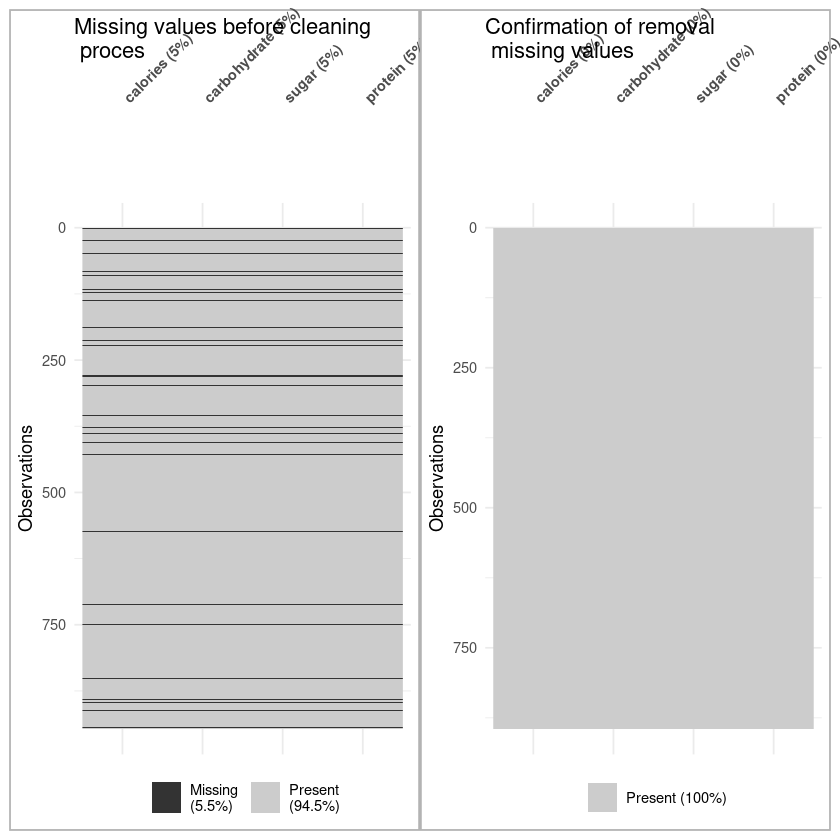

In [147]:
summary(traffic_site)

before_removal <- traffic_site %>%
select(calories, carbohydrate, sugar, protein) %>%
vis_miss() +
labs(
	title = "Missing values before cleaning \n proces"
) +
theme(
	axis.text.x = element_text(face = "bold"),
	plot.background = element_rect(color = "grey70", fill = "white", size = 1)
)
# About 5 percent is missing. 

data <- traffic_site %>% 
	filter(
		!is.na(calories) & 
		!is.na(carbohydrate) & 
		!is.na(sugar) &
		!is.na(protein)
	)

# Confirmation of removal NA rows
after_removal <- data %>%
select(calories, carbohydrate, sugar, protein) %>%
vis_miss() +
labs(
	title = "Confirmation of removal \n missing values"
) +
theme(
	axis.text.x = element_text(face = "bold"),
	plot.background = element_rect(color = "grey70", fill = "white", size = 1)
)

before_removal + after_removal + 
  plot_layout(widths = c(2, 2), heights = 4) 

## Data Cleaning 

First we defined correctly and confirmed the class of the 8 variables, we identified that the "category" variable contained 11 groups, instead of 10, but this was due the repeated "Chicken" category (as "Chicken" and "Chicken Breast"), also we identified a annotation in the "servings" variable: "as a snack"; as this annotation is not necessary we removed it. 

Using mostly dplyr tools we adjusted all the variables and then confirmed the 10 numbers of categories, and finally we compared the number of records by category before and after the missing values removal. We saw that the pattern of missing values is related with some groups of recipes, we will suggest to be more cautious in the registration of thece recipes (see figure below). 

[1] "The number of diferent categories are 10"

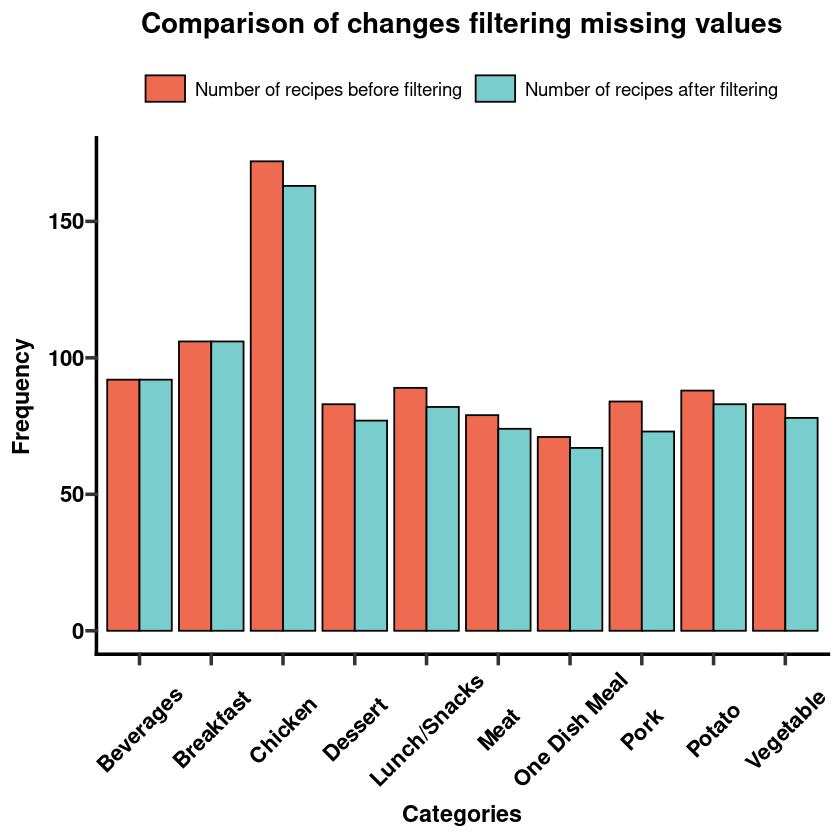

In [148]:
# Data Cleaning y Validation======================================================

cat_before_filter <- traffic_site %>% 
  mutate(
    category = ifelse(category == "Chicken Breast", "Chicken", category), 
  ) %>%
  mutate(
    category = factor(category)
  ) %>%
  group_by(category) %>%
  summarize(
    n = n()
  ) %>%
  arrange(desc(n))

prueba <- data %>% #Prueba will become the main df for the analysis
  mutate(
    recipe = as.numeric(recipe), 
    calories = as.numeric(calories), 
    carbohydrate = as.numeric(carbohydrate), 
    sugar = as.numeric(sugar), 
    protein = as.numeric(protein), 
    category = ifelse(category == "Chicken Breast", "Chicken", category), 
    servings = str_remove(servings, " as a snack"), 
    high_traffic = ifelse(is.na(high_traffic), as.numeric(0), as.numeric(1))
  ) %>%
  mutate(
    recipe = as.integer(recipe), 
    category = factor(category), 
    servings = as.integer(servings), 
    high_traffic = factor(high_traffic)
  )

cat_after_filter <- prueba %>%
  group_by(category) %>%
  summarize(n = n()) %>%
  arrange(desc(n))

paste0("The number of diferent categories are ", length(levels(prueba$category))) # Confirmation of the 10 different levels

cat_before_filter %>%
  left_join(cat_after_filter, by = "category", suffix = c("_before", "_after")) %>%
  select(category, n_before, n_after) %>%
  rename("Number of recipes before filtering" = n_before, 
         "Number of recipes after filtering" = n_after) %>%
  pivot_longer(2:3, names_to = "Event", values_to = "Count") %>%
  mutate(
    Event = factor(Event, levels = c("Number of recipes before filtering", "Number of recipes after filtering"))
  ) %>%
  ggplot(aes(x = category, y = Count, fill = Event)) +
  geom_col(position = position_dodge(), color = "black") + 
  labs(
    title = "Comparison of changes filtering missing values", 
    x = "Categories", y = "Frequency"
  ) +
  scale_fill_manual(values = c("#EE6A50", "#79CDCD")) +
  theme_prism() +
  theme(
    axis.text.x = element_text(angle = 45), 
    legend.position = "top"
  )

# 2. Exploratory Data Analysis

Our EDA were splited into the type of variables, their relationship and their characteristics.

## 2.1. Nutritional Features (Calories, Carbohydrate, Sugar and Protein):

These variables we thought are the most important in our dataset as this aspects specially protein and calories are the most asked values in new recipes because the new tendency of fitness and wellness across the world. For that we wanted to identify the distribution these variables with a boxplot (See boxplots below). 
We identified some interesting characteristics: The boxplot present a high number of positive outliers and no negative outliers, using the rule of IQR (Interquartile Range) * 1.5 we created a table to report the exact number of outliers. we detected that the positive outliers came from recipes with high amounts of sugar or protein, as this is "normal" in these type of recipes we decided to do not remove this recipes. 

Also the as there are no negative values according the boxplots we wanted to confirm the ranges and values of each individual variable using a very powerful tool from "skimr" package. We confirmed that there was no negative values, but the protein variable has a miniumum of 0 (2 cases), which could be a problem for transformations. At first we tought this could be a missing value, but according with the recipe it is normal that this kind of recipes has no protein values.   

With the tool from skimr we saw a mini-histogram for each variable, we detected a right-skewed distribution in all the four Nutritional Features. We focued in search more in detail of these finding

Group,negatives,positives
<chr>,<int>,<int>
Calories,0,47
Carbohydrate,0,58
Sugar,0,79
Protein,0,77


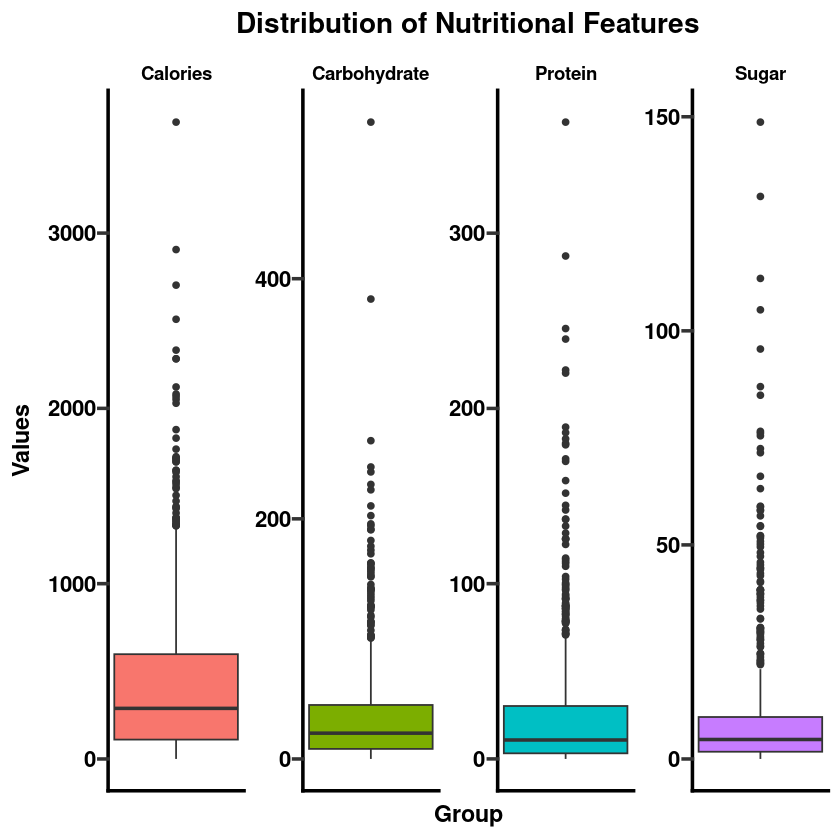

In [149]:
# Exploratory Data Analysis=====================================================
prueba %>% 
  select(calories, carbohydrate, sugar, protein) %>% 
  pivot_longer(1:4, names_to = "Group", values_to = "Values") %>% 
  mutate(
    Group = str_to_title(Group)
  ) %>%
  group_by(Group) %>% 
  ggplot(aes(y = Values, fill = Group)) +
  geom_boxplot(show.legend = FALSE) +
  labs(
    title = "Distribution of Nutritional Features", 
    x = "Group", 
    y = "Values" 
  ) +
  theme_prism() +
  theme(axis.text.x = element_blank(), 
        axis.ticks.x = element_blank()) +
  facet_wrap(~ Group, nrow = 1, scales = "free")

cols <- c("calories", "carbohydrate", "sugar", "protein")
outlier_counts <- data.frame(Group = character(), negatives = integer(), positivos = integer())

for (col in cols) {
  x <- prueba[[col]]
  q1 <- quantile(x, 0.25, na.rm = TRUE)
  q3 <- quantile(x, 0.75, na.rm = TRUE)
  iqr <- q3 - q1
  lim_inf <- q1 - 1.5 * iqr
  lim_sup <- q3 + 1.5 * iqr
  negatives <- sum(x < lim_inf)
  positives <- sum(x > lim_sup)
  outlier_counts <- rbind(outlier_counts, data.frame(Group = str_to_title(col), negatives, positives))
}

outlier_counts

skim_table <- skim(prueba[2:5])

In [176]:
tabl <- as_tibble(skim_table)

head(tabl)

skim_type,skim_variable,n_missing,complete_rate,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
numeric,calories,0,1,435.939196,453.02100,0.14,110.430,288.55,597.650,3633.16,▇▂▁▁▁
numeric,carbohydrate,0,1,35.069676,43.94903,0.03,8.375,21.48,44.965,530.42,▇▁▁▁▁
numeric,sugar,0,1,9.046547,14.67918,0.01,1.690,4.55,9.800,148.75,▇▁▁▁▁
numeric,protein,0,1,24.149296,36.36974,0.00,3.195,10.80,30.200,363.36,▇▁▁▁▁


### 2.1.1 Normality Assasement

Creating a full boxplot using ggplot2 we confirmed the right-skewed distribution and a exponential-decay-like pattern. This is highly suggestive of non-normal distribution, for that we ploted also a Q-Q plot to confirm it visually and runed a Shapiro-Wilk test to confimed statistically. In both cases the confirmation of non-normal distribution were succesfull. 

We choose to use the Box-Cox Transformation as our data has no negative values, we will compare with Q-Q plot, histogram and normality test to compare the goodnes of fit of the transformation before and after the transformation. As we identified two 0-values in the protein column we decided to add a conditional line adding 1e-8 grams of protein in those columns with 0 values.

The comparison between the data and the transformed-data is shown below in the two figures and in the table. In all the cases we confirmed normallity, these values are stored to used after in the modeling.

In [151]:
# Normality Assasment =====================================================

norm <- prueba %>% 
  select(calories, carbohydrate, sugar, protein) %>% 
  pivot_longer(1:4, names_to = "Group", values_to = "Values") %>% 
  mutate(
    Group = str_to_title(Group)
  ) %>%
  group_by(Group) %>% 
  ggplot(aes(sample = Values, color = Group)) +
  stat_qq(show.legend = FALSE) +
  stat_qq_line(show.legend = FALSE) +
  facet_wrap(~ Group, nrow = 1, scales = "free") +
  labs(
    title = "Q-Q Plots for Nutritional Features",
    x = "Theorical Quantiles", 
    y = "Ordered Values"
  ) +
  theme_prism()
  
 hist_p <- prueba %>% 
  select(calories, carbohydrate, sugar, protein) %>% 
  pivot_longer(cols = everything(), names_to = "Group", values_to = "Values") %>% 
  mutate(Group = str_to_title(Group)) %>%
  ggplot(aes(x = Values, fill = Group)) +
  geom_histogram(show.legend = FALSE) +
  geom_vline(
    data = . %>% group_by(Group) %>% summarise(mean_val = mean(Values)),
    aes(xintercept = mean_val),
    color = "black", linetype = "dashed", size = 1
  ) +
  geom_text(
    label = "Mean",
    aes(x = -Inf, y = Inf, vjust = 2, hjust = -1),
    color = "black", size = 5
  ) +
  geom_vline(
    data = . %>% group_by(Group) %>% summarise(median_val = median(Values)),
    aes(xintercept = median_val),
    color = "blue", linetype = "dashed", size = 1
  ) +
  geom_text(
    label = "Median",
    aes(x = -Inf, y = Inf, vjust = 3.5, hjust = -0.75),
    color = "blue", size = 5
  ) +
  labs(
    title = "Distribution of Nutritional Features", 
    y = "Frequency"
  ) +
  facet_wrap(~ Group, nrow = 1, scales = "free") +
  theme_prism()

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


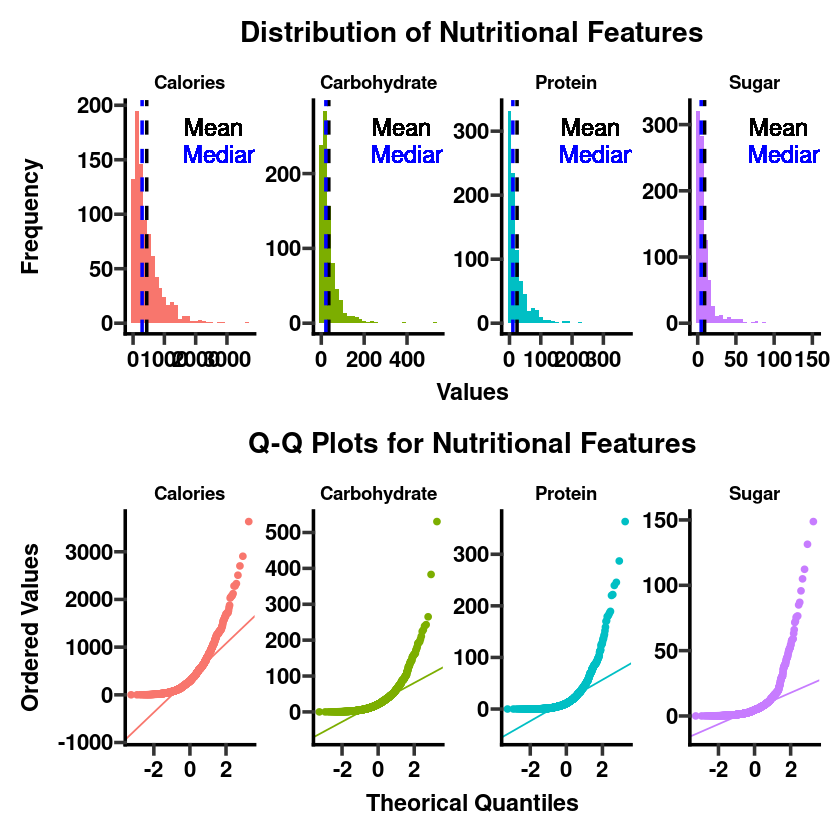

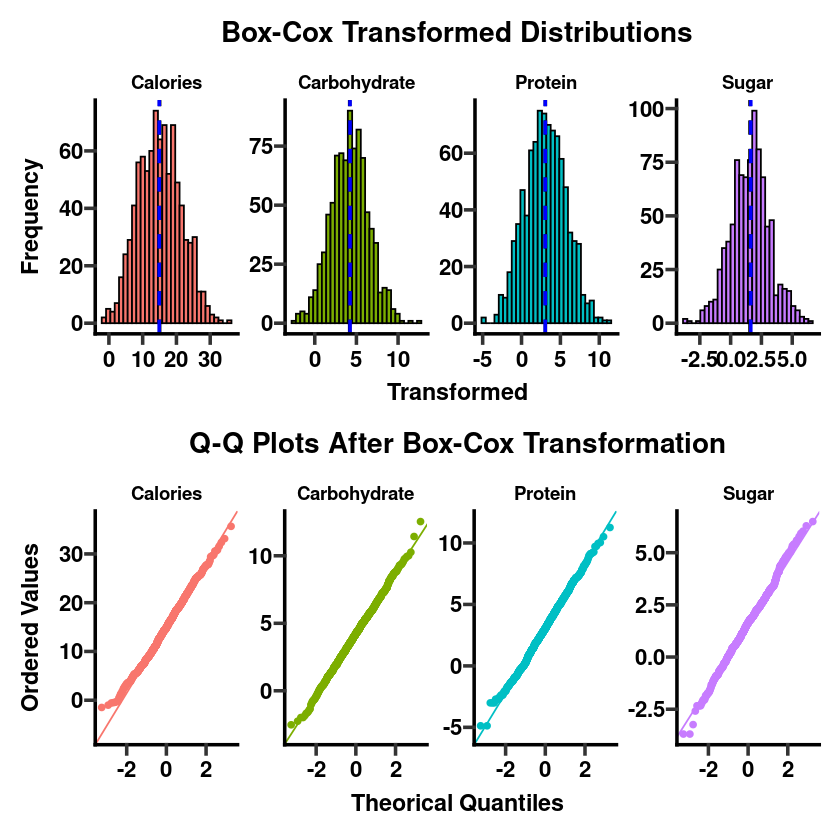

In [152]:
# Box-Cox Transformation =====================================================

prueba_long <- prueba %>% 
  select(calories, carbohydrate, sugar, protein) %>% 
  mutate((across(everything(), ~ ifelse(. == 0, 1e-8, .))))%>% #Here we added the little extra to do not have 0 values
  pivot_longer(cols = everything(), names_to = "Group", values_to = "Values") %>% 
  mutate(Group = str_to_title(Group))

# Box-Cox C: 
boxcox_trans <- prueba_long %>%
  group_by(Group) %>%
  group_split() %>%
  map_df(function(df) {
    trans <- BoxCoxTrans(df$Values, fudge = 0.02)
    df %>% mutate(Transformed = predict(trans, df$Values), 
                  lambda = trans$lambda)
  })

histBC <- boxcox_trans %>%
  ggplot(aes(x = Transformed, fill = Group)) +
  geom_histogram(show.legend = FALSE, bins = 30, color = "black") +
  geom_vline(
    data = boxcox_trans %>% group_by(Group) %>% summarise(mean_val = mean(Transformed)),
    aes(xintercept = mean_val),
    color = "black", linetype = "dashed", size = 1
  ) +
  geom_vline(
    data = boxcox_trans %>% group_by(Group) %>% summarise(median_val = median(Transformed)),
    aes(xintercept = median_val),
    color = "blue", linetype = "dashed", size = 1
  ) +
  labs(
    title = "Box-Cox Transformed Distributions", 
    y = "Frequency"
  ) +
  facet_wrap(~ Group, nrow = 1, scales = "free") +
  theme_prism()

normBC <- boxcox_trans %>%
  ggplot(aes(sample = Transformed, color = Group)) +
  stat_qq(show.legend = FALSE) +
  stat_qq_line(show.legend = FALSE) +
  facet_wrap(~ Group, nrow = 1, scales = "free") +
  labs(title = "Q-Q Plots After Box-Cox Transformation",
       x ="Theorical Quantiles", 
       y = "Ordered Values") +
  theme_prism()

before_norm <- hist_p / norm # Using patchwork we prepared the plots to compare visually before and after the transformation
after_norm <- histBC / normBC

before_norm
after_norm

In [153]:
# Confirmation of Normalization ================================================

boxcox_trans %>% 
  group_by(Group) %>%
  summarize(
    Shapiro_Wilk_p = shapiro.test(Values)$p.value, 
    Shapiro_Wilk_BC = shapiro.test(Transformed)$p.value, 
    Lambda = first(lambda)
  )

Group,Shapiro_Wilk_p,Shapiro_Wilk_BC,Lambda
<chr>,<dbl>,<dbl>,<dbl>
Calories,2.132307e-31,0.08739593,0.3
Carbohydrate,3.826677e-38,0.95670180,0.2
Protein,8.570083e-40,0.52701662,0.2
Sugar,1.018075e-42,0.12900638,0.1


### 2.1.2 Traffic Site and Nutritional Features

We assessed whether nutritional features differ between high‑traffic and low‑traffic recipes. Because the numeric variables are not normally distributed (right‑skewed), we used the Mann–Whitney U test and reported the medians as this metrics are robust in non-linear analysis. 
Results indicate that calories, protein, and sugar are significantly higher in high‑traffic recipes compared with low‑traffic recipes, whereas carbohydrate does not differ between groups. The median and p‑values are presented in the table below.

This analysis results interesting and we will consider these variables for our training model, specially the protein variable, which has the most significative of all the four variables evaluated.

Group,Median_Low_Traffic,Median_High_Traffic,Mann_Whitney_p
<chr>,<dbl>,<dbl>,<dbl>
Calories,267.775,305.09,0.0386220415
Carbohydrate,18.835,23.16,0.0524557123
Protein,8.775,12.03,0.0003573947
Sugar,5.185,4.25,0.0336728863


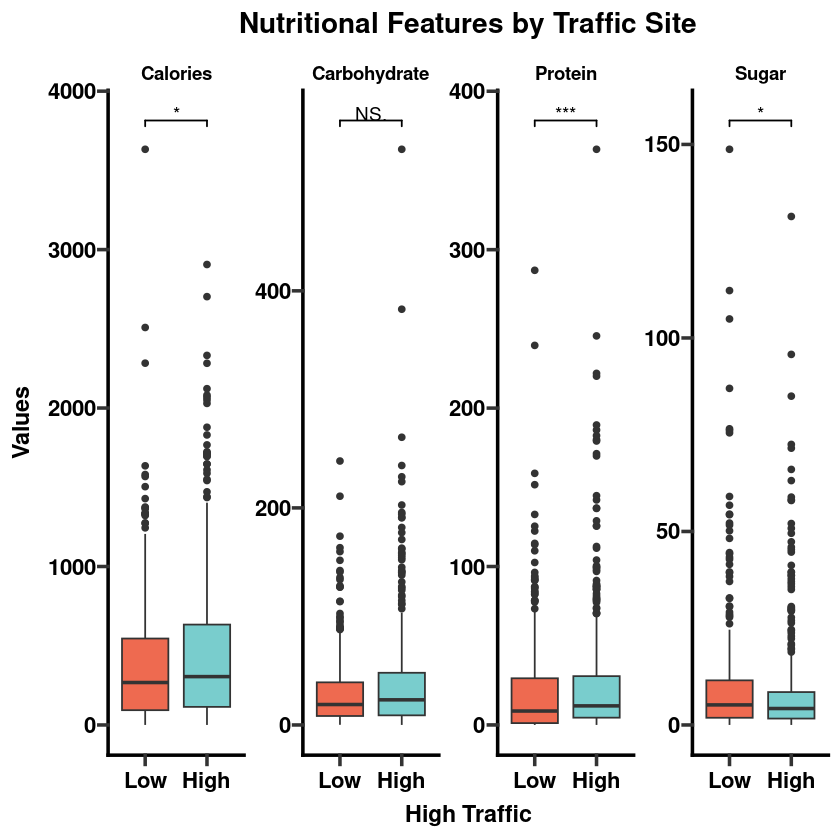

In [154]:
# Mann_Whitney U Test ============================================================

prueba %>% 
  select(calories, carbohydrate, sugar, protein, high_traffic) %>%
  pivot_longer(cols = c(calories, carbohydrate, sugar, protein), 
               names_to = "Group", values_to = "Values") %>%
  mutate(
    Group = str_to_title(Group)
  ) %>%
  group_by(Group) %>%
  summarize(
    Median_Low_Traffic = median(Values[high_traffic == 0]), 
    Median_High_Traffic = median(Values[high_traffic == 1]),
    Mann_Whitney_p = wilcox.test(Values ~ high_traffic)$p.value
  )


prueba %>% 
  select(calories, carbohydrate, sugar, protein, high_traffic) %>%
  pivot_longer(cols = c(calories, carbohydrate, sugar, protein), 
               names_to = "Group", values_to = "Values") %>%
  mutate(
    Group = str_to_title(Group), 
    high_traffic = dplyr::recode(high_traffic, "0" = "Low", "1" = "High")
  ) %>%
  ggplot(aes(x = high_traffic, y = Values, fill = high_traffic)) +
  geom_boxplot() +
  labs(
    title = "Nutritional Features by Traffic Site", 
    x = "High Traffic", 
    y = "Values", 
    fill = "High Traffic"
  ) +
  geom_signif(
    comparisons = list(c("Low", "High")),
    test = "wilcox.test",
    map_signif_level = TRUE,
    tip_length = 0.01,
    textsize = 4,
    vjust = 0.5
  ) +
  scale_fill_manual(values = c("#EE6A50", "#79CDCD"), 
                    labels = c("Low", "High")) +
  theme_prism() +
  theme(
    axis.text.x = element_text(face = "bold"), 
    legend.position = "none"
  ) +
  facet_wrap(~ Group, nrow = 1, scales = "free")

### 2.1.3 Correlation of Nutritional Features 

We caclulated if there was correlation between the Nutritional Features, surprisingly there was no high correlation, all the r values obtained were too close to zero. So we conclude that this Features alone do not predict each other Feature in a linear relationship. 

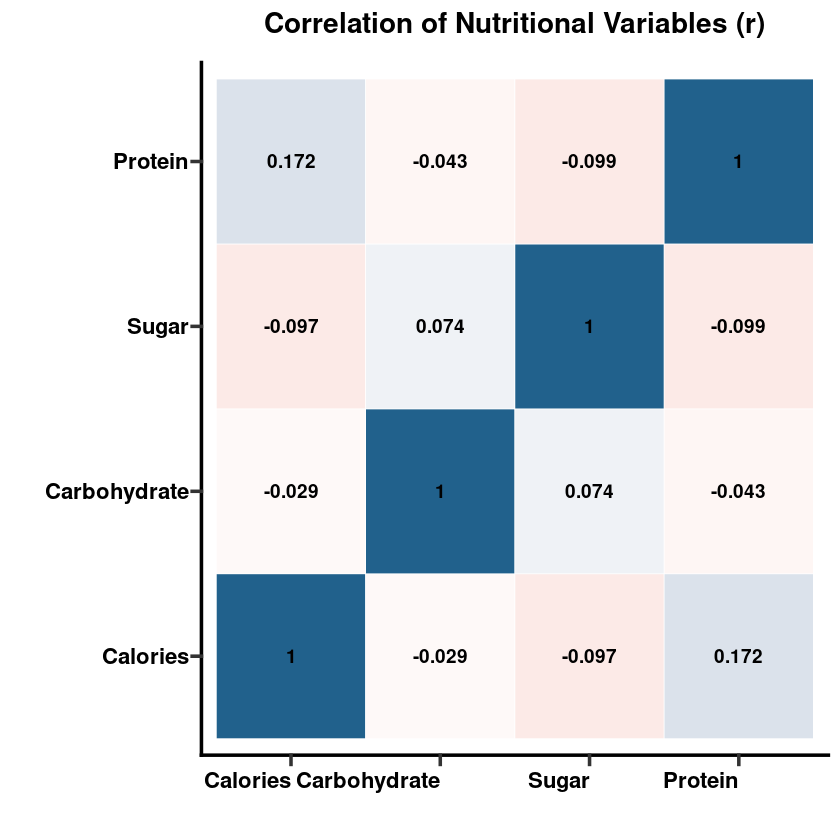

In [155]:
# Correlation and Heatmap =====================================================

vars <- prueba %>%
  select(calories, carbohydrate, sugar, protein) %>% 
  rename(Calories = "calories") %>% 
  rename(Carbohydrate = carbohydrate) %>% 
  rename(Sugar = sugar) %>% 
  rename(Protein = protein)

cor_matrix <- cor(vars, use = "complete.obs")

cor_long <- as.data.frame(as.table(cor_matrix))

ggplot(cor_long, aes(Var1, Var2, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(Freq, 3)), size = 4, fontface = "bold") +
  scale_fill_gradient2(low = "#B22222", high = "#21618C", mid = "white", 
                       midpoint = 0, limit = c(-1, 1), 
                       name = "Correlation") +
  labs(title = "Correlation of Nutritional Variables (r)",
       x = "", y = "") +
  theme_prism() +
  theme(axis.text.x = element_text(angle = 0, hjust = 1), legend.position = "none")

## 2.2. Categorical Analysis

### 2.2.1 Traffic Site and Category

For our categorical analysis we first identified the distribution and proporiton of high vs low traffic site recipes groups. We presented the results in a barplot for distribution and a pie chart for proportion (as there are just 2 groups there is an easy-interpretable plot). 

We found that 59.8% (535 recipes) of published recipes on the site received high traffic. To investigate whether popularity is associated with recipe category, we performed a $\chi^2$ test of independence, which showed a statistically significant association between category and traffic status. In particular, recipes in the Vegetables category were the most frequently high‑traffic (~99% high), while recipes in the Beverages category were predominantly low‑traffic (~94.6% low). These results indicate that recipe category is a strong determinant of a recipe’s popularity on our website.

This result could be justified by the wellness tendencies in the recent years, as this tendency is growing we suggest to pay special attention to vegetables recipes. 

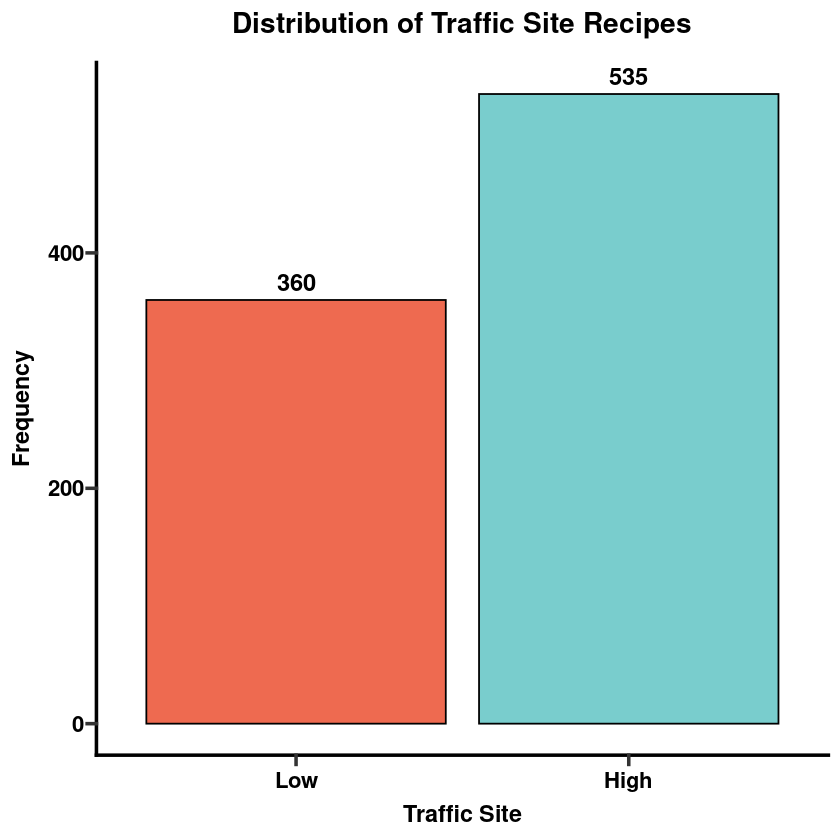

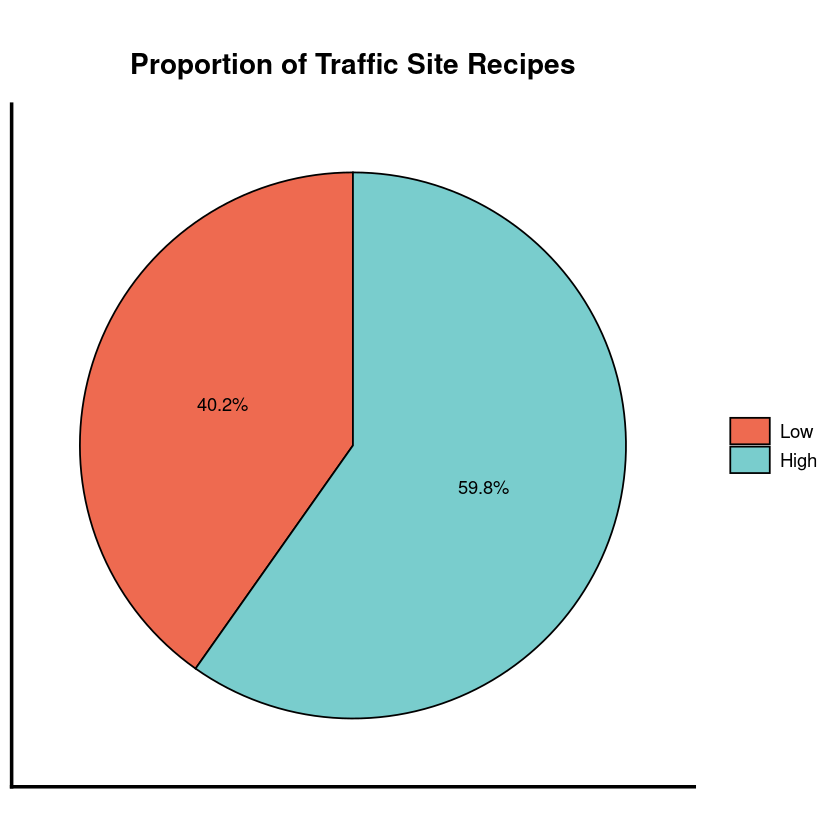

In [156]:
# Statistical Analysis ============================================================

prop <- prueba %>% 
  group_by(high_traffic) %>% 
  summarize(
    frequency = n()
  ) %>% 
  mutate(high_traffic = dplyr::recode(high_traffic, "0" = "Low", "1" = "High")) %>%
  ggplot(aes(x = high_traffic, y = frequency, fill = high_traffic)) +
  geom_col(color = "black", show.legend = FALSE) +
  labs(
    title = "Distribution of Traffic Site Recipes", 
    x = "Traffic Site", 
    y = "Frequency"
  ) +
  geom_text(aes(label = frequency),
		    position = position_dodge(width = 0.9), 
		   	vjust = -0.5, 
		   	size = 5, 
		   	fontface = "bold") +
  scale_fill_manual(values = c("#EE6A50", "#79CDCD"), 
                    labels = c("High", "Low")) +
  theme_prism()

# Pie Chart Proportion of High Traffic Sites
pie <- prueba %>% 
  group_by(high_traffic) %>% 
  summarise(
    Frequency = n()) %>% 
  mutate(prop = Frequency / sum(Frequency)) %>%
  mutate(high_traffic = factor(high_traffic, levels = c("Low" = "0", "High" = "1"), ordered = TRUE)) %>%
  ggplot(aes(x = "", y = prop, fill = high_traffic)) +
  geom_bar(stat = "identity", width = 1, color = "black") +
  coord_polar("y", start = 0) +
  geom_text(aes(label = scales::percent(prop, accuracy = 0.1)), 
            position = position_stack(vjust = 0.5)) +
  labs(
    title = "Proportion of Traffic Site Recipes", 
    fill = "High Traffic"
  ) +
  scale_fill_manual(values = c("#EE6A50", "#79CDCD"), 
                    labels = c("Low", "High")) +
  theme_prism() +
  theme(axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        axis.text.x = element_blank(),
        axis.text.y = element_blank(),
        axis.ticks = element_blank(), 
        panel.border = element_blank())

prop 
pie

`summarise()` has grouped output by 'category'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'category'. You can override using the
`.groups` argument.


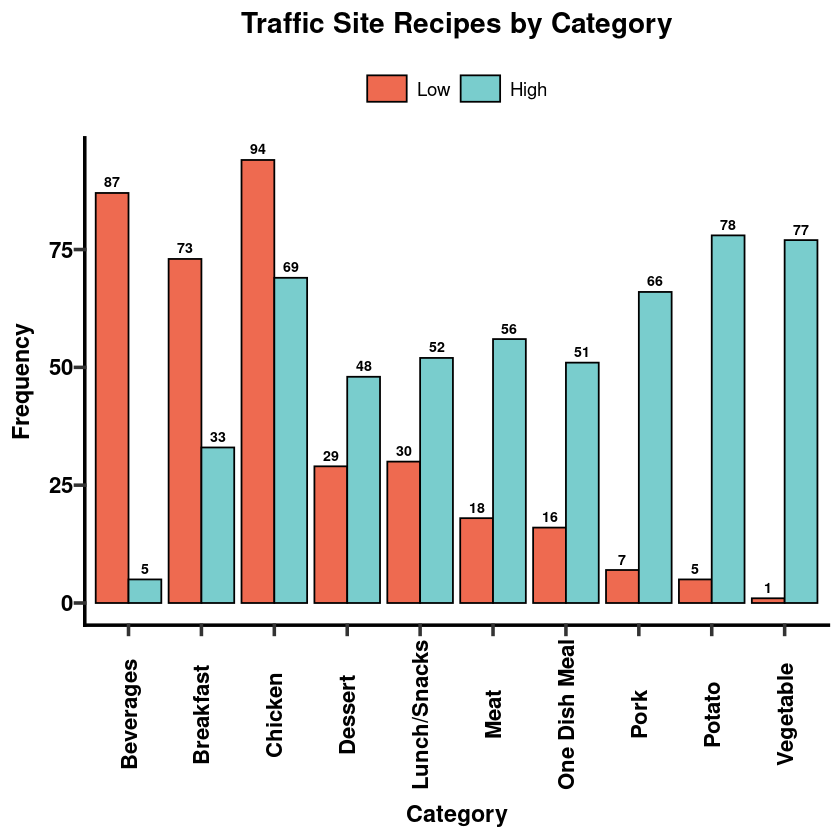


	Pearson's Chi-squared test

data:  .
X-squared = 303.74, df = 9, p-value < 2.2e-16


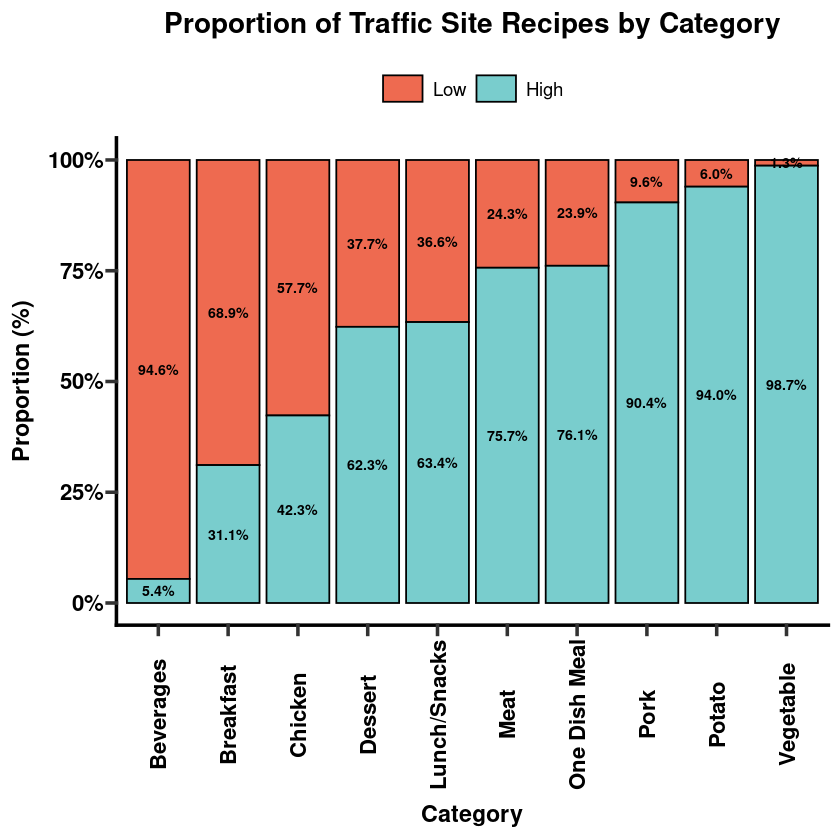

In [157]:
# High Traffic ~ Category 

HT_cat <- prueba %>%
  group_by(category, high_traffic) %>%
  summarise(
    frequency = n()
  ) %>%
  mutate(
    category = str_to_title(category), 
    high_traffic = dplyr::recode(high_traffic, "0" = "Low", "1" = "High")
  ) %>%
  ggplot(aes(x = category, y = frequency, fill = high_traffic)) +
  geom_col(position = position_dodge(), color = "black") +
  labs(
    title = "Traffic Site Recipes by Category", 
    x = "Category", 
    y = "Frequency", 
    fill = "High Traffic"
  ) +
  geom_text(
    aes(label = frequency), 
    position = position_dodge(width = 0.9), 
    vjust = -0.5, 
    size = 3, 
    fontface = "bold"
  ) +
  scale_fill_manual(values = c("#EE6A50", "#79CDCD")) +
  theme_prism() +
  theme(
    axis.text.x = element_text(angle = 90), 
    legend.position = "top"
  )

HT_cat_prop <- prueba %>%
  group_by(category, high_traffic) %>%
  summarise(frequency = n()) %>%
  group_by(category) %>%
  mutate(prop = frequency / sum(frequency)) %>%
  mutate(
    category = str_to_title(category), 
    high_traffic = dplyr::recode(high_traffic, "0" = "Low", "1" = "High")
  ) %>%
  ggplot(aes(x = category, y = prop, fill = high_traffic)) +
  geom_col(color = "black") +
  geom_text(aes(label = scales::percent(prop, accuracy = 0.1)),
            position = position_stack(vjust = 0.5),
            size = 3, fontface = "bold") +
  labs(
    title = "Proportion of Traffic Site Recipes by Category", 
    x = "Category", 
    y = "Proportion (%)", 
    fill = "High Traffic"
  ) +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = c("#EE6A50", "#79CDCD")) +
  theme_prism() +
  theme(
    axis.text.x = element_text(angle = 90), 
    legend.position = "top"
  )

HT_cat 
HT_cat_prop

prueba %>%
  mutate(
    category = str_to_title(category), 
    high_traffic = dplyr::recode(high_traffic, "0" = "Low", "1" = "High")
  ) %>% 
  tabyl(category, high_traffic) %>%
  chisq.test()


### 2.2.2 Traffic Site and Servings

Aditionally of categories, we examined whether the number of servings is associated with recipe popularity. 

Although the 4‑servings group initially appeared to have a higher proportion of high‑traffic recipes as shown in the first figure of this section, after converting counts to relative proportions and performing a $\chi^2$-test of independence we found no evidence of association (p = 0.53). 

In other words, we fail to reject the null hypothesis and conclude there is no statistically significant relationship between servings and traffic status in this database. As a comment, we thought these variable and category will be associated with the traffic site popularity, but with 'servings' this was no the case, but this is a important variable we will use this variable to create a feature engeeniring variables to train the models (see below).  

`summarise()` has grouped output by 'servings'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'servings'. You can override using the
`.groups` argument.


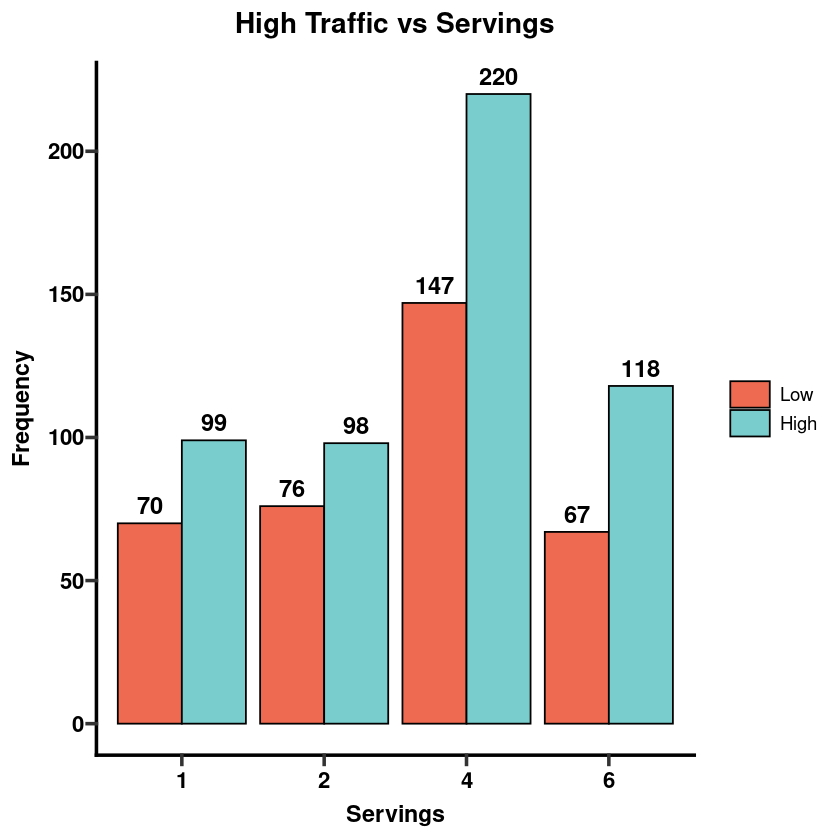


	Pearson's Chi-squared test

data:  .
X-squared = 2.2042, df = 3, p-value = 0.5311


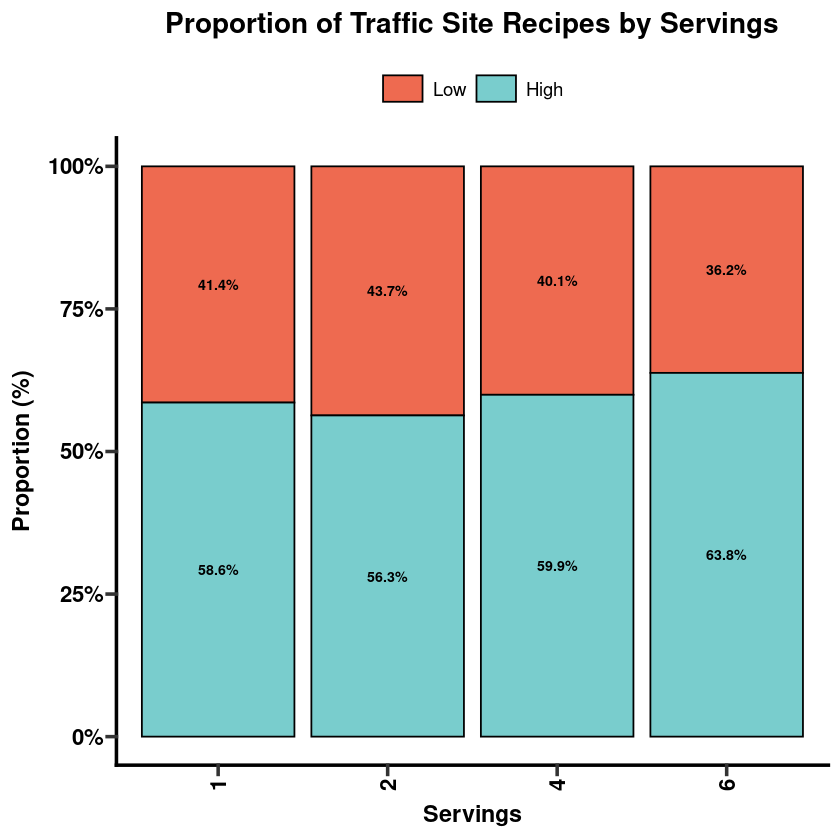

In [158]:
# High Traffic ~ Servings

HT_ser <- prueba %>% 
  group_by(servings, high_traffic) %>% 
  mutate(
    high_traffic = dplyr::recode(high_traffic, "0" = "Low", "1" = "High"), 
    servings = factor(servings)
  ) %>% 
  summarize(
    n = n()
  ) %>%
  ggplot(aes(x = servings, y = n, fill = high_traffic)) +
  geom_col(position = position_dodge(), color = "black") +
  labs(
    title = "High Traffic vs Servings", 
    x = "Servings", 
    y = "Frequency", 
    fill = "High Traffic"
  ) +
  geom_text(
    aes(label = n), 
    position = position_dodge(width = 0.9), 
    vjust = -0.5, 
    size = 5, 
    fontface = "bold"
  ) +
  scale_fill_manual(values = c("#EE6A50", "#79CDCD")) +
  theme_prism()

HT_ser_prop <-   prueba %>%
  group_by(servings, high_traffic) %>%
  summarise(frequency = n()) %>%
  group_by(servings) %>%
  mutate(prop = frequency / sum(frequency)) %>%
  mutate(
    high_traffic = dplyr::recode(high_traffic, "0" = "Low", "1" = "High"),
    servings = factor(servings)
  ) %>%
  ggplot(aes(x = servings, y = prop, fill = high_traffic)) +
  geom_col(color = "black") +
  geom_text(aes(label = scales::percent(prop, accuracy = 0.1)),
            position = position_stack(vjust = 0.5),
            size = 3, fontface = "bold") +
  labs(
    title = "Proportion of Traffic Site Recipes by Servings", 
    x = "Servings", 
    y = "Proportion (%)", 
    fill = "High Traffic"
  ) +
  scale_y_continuous(labels = scales::percent) +
  scale_fill_manual(values = c("#EE6A50", "#79CDCD")) +
  theme_prism() +
  theme(
    axis.text.x = element_text(angle = 90), 
    legend.position = "top"
  )

HT_ser 
HT_ser_prop

prueba %>%
  mutate(
    high_traffic = dplyr::recode(high_traffic, "0" = "Low", "1" = "High")
  ) %>% 
  tabyl(servings, high_traffic) %>%
  chisq.test()

# 3. Model Development

To predict correctly 80% of the times which recipe will have high traffic site in our website, we need to develop a **Classification** model, we have some models, we want to train a baseline model, which will be in this case **Logistic Regression**, and for our comparison model we chosse to include not one but two models: **Random Forest** and **Gradient Boosting**. 

Justification: 
1. Logistic Regression: Is a simple model, interpretable and can help us to understand the relationship between the variables. 
2. Random Forest: Is a powerfull model, reduces variance by combining multiple decision trees, can handle non-linear relationships and most importantly we can obtain the feature importance measures.
3. Gradient Boosting: Builds trees sequentially, optimizing for residual errors at each step. This approach often yields strong predictive performance.

## 3.1 Data preparation

### 3.1.1 Transformed Nutritional Features and additional Variables

Before the training of our models, we needed to prepare the dataset. First we incorporated the Box-Cox transformed nutritional features from the previous section, also we engineered new variables representing the relationship between nutritional features and the number of servings. 

But, since these engineered variables were right-skewed, we applied an additional Box-Cox transformation to normalize their distribution.

In [159]:
#Wide Format
prueba_trans <- boxcox_trans %>%
  select(Group, Transformed) %>%
  group_by(Group) %>%
  mutate(row_id = row_number()) %>%   
  ungroup() %>%
  pivot_wider(names_from = Group, values_from = Transformed) %>%
  select(-row_id)

# Bindning both groups and adding new features
prueba_final <- prueba %>%
  bind_cols(prueba_trans) %>% 
  rename(
    calories_BC = Calories, 
    carbohydrate_BC = Carbohydrate, 
    protein_BC = Protein,
    sugar_BC = Sugar
  ) %>% 
  mutate(
    calories_per_serving = calories/servings, 
    carbohydrate_per_serving = carbohydrate/servings,
    protein_per_serving = protein/servings, 
    sugar_per_serving = sugar/servings
  )  

# Normalization of new Features
prueba_long_per_serving <- prueba_final %>%
  dplyr::select(calories_per_serving, carbohydrate_per_serving, sugar_per_serving, protein_per_serving) %>%
  mutate(across(everything(), ~ ifelse(. == 0, 1e-8, .))) %>%
  pivot_longer(cols = everything(), names_to = "Group", values_to = "Values") %>%
  mutate(Group = str_c(Group, "_BC")) # opcional, para nombre con mayúscula inicial

boxcox_trans_per_serving <- prueba_long_per_serving %>%
  group_by(Group) %>%
  group_split() %>%
  map_df(function(df) {
    trans <- BoxCoxTrans(df$Values, fudge = 0.01)
    df %>% mutate(Transformed = predict(trans, df$Values),
                  lambda = trans$lambda)
  })

prueba_trans_per_serving_wide <- boxcox_trans_per_serving %>%
  select(Group, Transformed) %>%
  group_by(Group) %>%
  mutate(row = row_number()) %>%
  pivot_wider(names_from = Group, values_from = Transformed) %>%
  select(-row)

prueba_final <- bind_cols(prueba_final, prueba_trans_per_serving_wide)

### 3.1.2 Target Encoding for Category 

As we identified the category variable one of the most important we applied target encoding of the 10 categories. The resulting numeric values were then integrated into the final dataset. 

We selected this technique because it generates a single numeric column that captures the correlation between each category and the target variable. This encoding is particularly suitable for our database structure, as it preserves predictive signal while reducing dimensionality.

In [160]:
# Target Encoding 
category_encoding <- prueba_final %>%
  group_by(category) %>%
  summarize(category_te = mean(as.numeric(as.character(high_traffic))), .groups = "drop")

prueba_final <- prueba_final %>%
  left_join(category_encoding, by = "category")

glimpse(prueba_final)

Rows: 895
Columns: 21
$ recipe                      <int> 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14…
$ calories                    <dbl> 35.48, 914.28, 97.03, 27.05, 691.15, 183.9…
$ carbohydrate                <dbl> 38.56, 42.68, 30.56, 1.85, 3.46, 47.95, 3.…
$ sugar                       <dbl> 0.66, 3.09, 38.63, 0.80, 1.65, 9.75, 0.40,…
$ protein                     <dbl> 0.92, 2.88, 0.02, 0.53, 53.93, 46.71, 32.4…
$ category                    <fct> Potato, Breakfast, Beverages, Beverages, O…
$ servings                    <int> 4, 1, 4, 4, 2, 4, 4, 6, 2, 1, 6, 4, 4, 4, …
$ high_traffic                <fct> 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, …
$ calories_BC                 <dbl> 6.391313, 22.441894, 9.817418, 5.631226, 2…
$ carbohydrate_BC             <dbl> 5.3800013, 5.5929003, 4.9083348, 0.6546320…
$ protein_BC                  <dbl> -0.08269021, 1.17800851, -2.71347474, -0.5…
$ sugar_BC                    <dbl> -0.4070011, 1.1942718, 4.4109453, -0.22067…
$ calories_per_ser

## 3.2 Feature Engineering
We introduced a new variable, std, defined as the standard deviation of the raw nutritional variables (calories, carbohydrate, sugar, protein). This feature is intended to capture internal variability among nutrients and provide additional predictive power for the high_traffic classification.

## 3.3 Target Variable
The dependent variable is high_traffic, recoded as a binary factor with labels "Low" and "High".
Our modeling goal is to correctly classify at least 80% of the **high-traffic recipes**.

## 3.4 Predictors
The following groups of predictors were included:
- Normalized nutritional features: calories_BC, carbohydrate_BC, sugar_BC, protein_BC
- Normalized nutritional features per serving: protein_per_serving_BC, sugar_per_serving_BC, carbohydrate_per_serving_BC, calories_per_serving_BC
- Categorical features: transformed using target encoding (category_te)
- Number of servings: servings
- Dispersion variable: std
We selected these predictors based on their potential impact on model performance and predictive value.

## 3.5 Preprocessing Pipeline
Applied target encoding to all categorical predictors.
Centered and scaled all numeric predictors to improve model stability, particularly for linear models such as logistic regression.

## 3.6 Train/Test Split
A stratified split was performed with an 80/20 proportion, ensuring balanced representation of the target variable.
Both training and test sets were processed using the recipe to guarantee consistent preprocessing.

In [161]:
prueba_final <- prueba_final %>%
  mutate(std = apply(select(., calories, carbohydrate, sugar, protein), 1, sd, na.rm = TRUE)) #Creation of the new variable std

# Target como factor binario (para Logistic y RF)
prueba_final_final <- prueba_final %>%
  mutate(high_traffic = factor(high_traffic, levels = c("0","1"), labels = c("Low","High")))

# Prepare for cooking! Here is the recipe c: 
rec <- recipe(high_traffic ~ calories_BC + 
                carbohydrate_BC + sugar_BC + 
                protein_BC + std + protein_per_serving_BC + 
                category_te + sugar_per_serving_BC + carbohydrate_per_serving_BC +
                calories_per_serving_BC + servings,
              data = prueba_final_final) %>%
  step_dummy(all_nominal_predictors(), one_hot = TRUE) %>%
  step_center(all_numeric_predictors()) %>%
  step_scale(all_numeric_predictors())

# Split train/test
set.seed(10) #For reproducibility c: 
trainIndex <- createDataPartition(prueba_final_final$high_traffic, p = 0.8, list = FALSE)
train <- prueba_final_final[trainIndex, ]
test  <- prueba_final_final[-trainIndex, ]

# Preprocessing for train and test
prep_rec <- prep(rec, training = train)
train_processed <- bake(prep_rec, new_data = train)
test_processed  <- bake(prep_rec, new_data = test)

## 3.7 Classification Threshold

A classification threshold of 0.60 was applied, meaning recipes with probability > 0.60 were labeled as **High traffic**. This threshold was selected because it provides a balanced results across evaluation metrics and achieves approximately 80% precision in identifying high-traffic recipes.

## 3.8 Model Fitting

### 3.8.1 Logistig Regression (Base Model)

We trained a logistic regression model using all preprocessed predictors. The model was fitted on the training dataset with a **binomial** family specification. 
Predictions on the test set were obtained as probabilities, which were then classified into High or Low Traffic using the **0.60 threshold**.

In [162]:
# 1. Logistic Regression

log_model <- glm(high_traffic ~ ., data = train_processed, family = binomial)

log_prob <- predict(log_model, newdata = test_processed, type = "response")
log_class <- ifelse(log_prob > 0.60, "High", "Low")

### 3.8.2 Random Forest 

We then trained a Random Forest model with 500 trees and `mtry = 3` (Number of variables randomly sampled as candidates at each split). We considered the same Classification threshold as the Logistic Regression Model. 

In [163]:
# 2. Random Forest
rf_model <- randomForest(high_traffic ~ ., data = train_processed, ntree = 500, mtry = 3)

rf_prob <- predict(rf_model, newdata = test_processed, type = "prob")[, "High"]
rf_class <- ifelse(rf_prob > 0.6, "High", "Low")

### 3.8.3 Gradient Boosting

For gradient boosting, the target variable was explicitly recoded into binary format `(0-1)`.  The model was trained with 1,000 trees, a maximum interaction depth of 3, a learning rate of 0.01, and a minimum of 10 observations per node. 

Just as with Random Forest we used the same threshold of 0.60.

In [164]:
# 3. Gradient Boosting 

# Convertir target a 0/1 explícitamente para gbm
train_gbm <- train_processed %>%
  mutate(high_traffic = ifelse(high_traffic == "High", 1, 0))
test_gbm <- test_processed %>%
  mutate(high_traffic = ifelse(high_traffic == "High", 1, 0))

set.seed(10)
gbm_model <- gbm(
  formula = high_traffic ~ .,
  distribution = "bernoulli",
  data = na.omit(train_gbm), # Usar na.omit para asegurar que no haya NAs
  n.trees = 1000,
  interaction.depth = 3,
  shrinkage = 0.01,
  n.minobsinnode = 10,
  verbose = FALSE
)

gbm_prob <- predict(gbm_model, newdata = test_gbm, n.trees = 1000, type = "response")
gbm_class <- ifelse(gbm_prob > 0.6, 1, 0)

# 4. Model Evaluation

For model evaluation, we extracted the following metrics:
- Accuracy: Measures the overall proportion of correctly classified observations. While useful as a general benchmark, accuracy can be misleading in imbalanced datasets, as in our case.
- **Precision**: The most important metric in our analysis, as we aim to minimize false positives. As requested by the product team, our objective is to ensure that predictions of High Traffic recipes are correct **at least 80% of the time**.
- Recall: The proportion of actual positives correctly identified.
- F1 Score: The harmonic mean of precision and recall, balancing both metrics.
- AUC (Area Under the Curve): Represents the model’s ability to distinguish between classes across all thresholds.
- ROC Curve: Provides a visual tool for selecting an optimal threshold and comparing model performance beyond a single cutoff. It also allows us to evaluate models comprehensively across different operating points.

## 4.1 Model Evaluation Metrics 

For each model, evaluation metrics were extracted using the test dataset. 
We employed confusion matrices to calculate **Accuracy**, representing the overall proportion of correctly classified recipes.
From the same predictions, we computed **Precision, Recall, and the F1 Score** to capture the balance between false positives and false negatives. 

Precision was emphasized as the key metric, aligned with the product team’s requirement to correctly identify High Traffic recipes at least 80% of the time.

In addition, we generated ROC curves and calculated the AUC to assess the discriminative ability of each model across different thresholds. 

These metrics were extracted using standard R packages (caret, pROC, and MLmetrics), ensuring reproducibility and consistency across models.

In [165]:
# 1. Logistic Regression Evaluation
cm_log <- confusionMatrix(factor(log_class, levels = c("Low","High")), test_processed$high_traffic)
accuracy_log <- cm_log$overall['Accuracy']

roc_log <- roc(test_processed$high_traffic, log_prob)
auc_log <- auc(roc_log)

precision_log <- Precision(test_processed$high_traffic, factor(log_class, levels = c("Low","High")), positive = "High")
recall_log <- Recall(test_processed$high_traffic, factor(log_class, levels = c("Low","High")), positive = "High")
f1_log <- F1_Score(test_processed$high_traffic, factor(log_class, levels = c("Low","High")), positive = "High")

Setting levels: control = Low, case = High

Setting direction: controls < cases



In [166]:
# 2. Random Forest Evaluation

cm_rf <- confusionMatrix(factor(rf_class, levels = c("Low", "High")), test_processed$high_traffic)
accuracy_rf <- cm_rf$overall['Accuracy']

roc_rf <- roc(test_processed$high_traffic, rf_prob)
auc_rf <- auc(roc_rf)

precision_rf <- Precision(test_processed$high_traffic, factor(rf_class, levels = c("Low","High")), positive = "High")
recall_rf <- Recall(test_processed$high_traffic, factor(rf_class, levels = c("Low","High")), positive = "High")
f1_rf <- F1_Score(test_processed$high_traffic, factor(rf_class, levels = c("Low","High")), positive = "High")

Setting levels: control = Low, case = High

Setting direction: controls < cases



In [167]:
# 3. Gradient Boosting Evaluation

actual_gbm_factor <- factor(test_gbm$high_traffic, levels = c(0, 1), labels = c("Low", "High"))
pred_gbm_factor <- factor(gbm_class, levels = c(0, 1), labels = c("Low", "High"))
cm_gbm <- confusionMatrix(pred_gbm_factor, actual_gbm_factor)
accuracy_gbm <- cm_gbm$overall['Accuracy']

roc_gbm <- roc(test_gbm$high_traffic, gbm_prob)
auc_gbm <- auc(roc_gbm)

precision_gbm <- Precision(test_gbm$high_traffic, gbm_class, positive = 1)
recall_gbm <- Recall(test_gbm$high_traffic, gbm_class, positive = 1)
f1_gbm <- F1_Score(test_gbm$high_traffic, gbm_class, positive = 1)

Setting levels: control = 0, case = 1

Setting direction: controls < cases



## 4.2 Model Metrics Comparison

After storing the evaluation metrics, we prepared a summary table to compare model performance.
- **Precision** ≥ 80% was achieved across all models. The highest precision was obtained by the Random Forest (82%), although its recall was relatively low (68%).
- **Logistic Regression** achieved 81% precision with a higher recall of 76%, making it the **most balanced and stable model**.
- Gradient Boosting yielded the lowest precision (81%) and recall (68%), resulting in slightly weaker overall performance compared to the other models.

Overall, Logistic Regression delivered the strongest and most consistent results, including the highest accuracy. 

This outcome highlights the value of simplicity in modeling, echoing **Robert Tibshirani’s remark: *"Simple is good."***

In [168]:
# Model Comparison

results <- data.frame(
  Model = c("Logistic Regression", "Random Forest", "Gradient Boosting"),
  Precision = c(precision_log, precision_rf, precision_gbm),
  Accuracy = c(accuracy_log, accuracy_rf, accuracy_gbm),
  Recall = c(recall_log, recall_rf, recall_gbm),
  F1 = c(f1_log, f1_rf, f1_gbm),
  AUC = c(auc_log, auc_rf, auc_gbm)
)

print(results)

                Model Precision  Accuracy    Recall        F1       AUC
1 Logistic Regression 0.8118812 0.7541899 0.7663551 0.7884615 0.8417705
2       Random Forest 0.8202247 0.7206704 0.6822430 0.7448980 0.7960800
3   Gradient Boosting 0.8111111 0.7150838 0.6822430 0.7411168 0.8047767


## 4.3 ROC Curve

The ROC curves for all models were plotted in the same layout to facilitate direct comparison. Among them, **Logistic Regression** achieved the highest accuracy and demonstrated the most stable discriminative performance across thresholds. 
The ROC visualization confirmed that Logistic Regression consistently outperformed the other models, supporting its selection as the preferred approach.

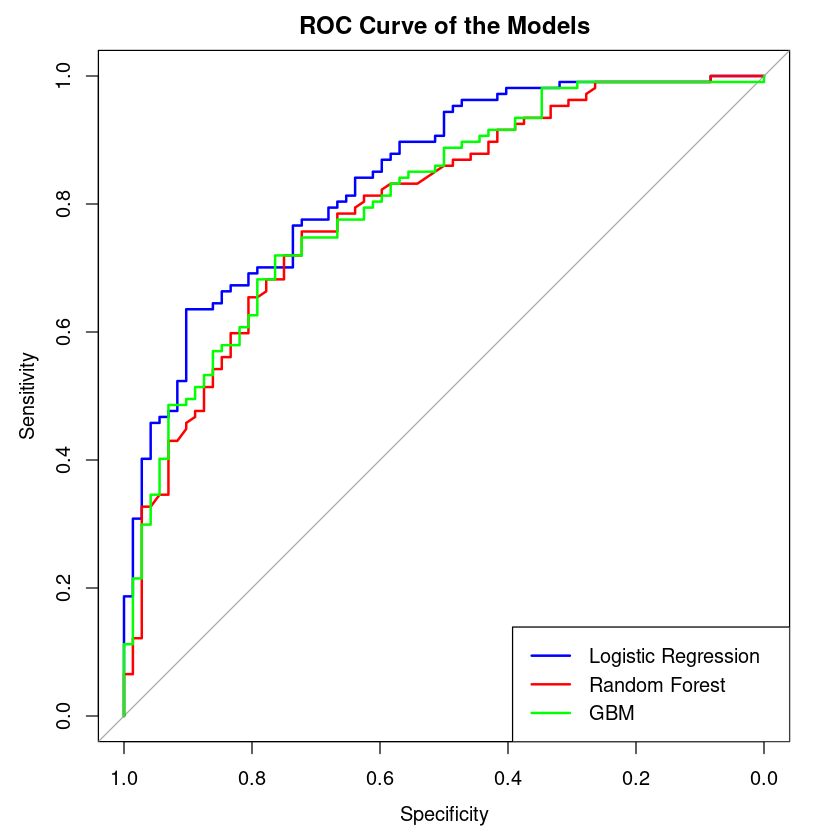

In [169]:
# ROC Curve

plot(roc_log, col = "blue", main = "ROC Curve of the Models")
plot(roc_rf, col = "red", add = TRUE)
plot(roc_gbm, col = "green", add = TRUE)
legend("bottomright", legend = c("Logistic Regression", "Random Forest", "GBM"),
       col = c("blue", "red", "green"), lwd = 2)

## 4.4 Variables Importance Analysis 

To better understand the contribution of individual predictors, we extracted variable importance measures from each model and visualized them using bar plots: 

- Logistic Regression: Importance was derived from the absolute **t-statistics of the coefficients**. This approach highlights variables with the strongest linear relationship to the target.
- Random Forest: Importance was measured using the **Mean Decrease in Gini Index**, which reflects how much each variable contributes to reducing impurity across the ensemble of trees.
- Gradient Boosting: Importance was calculated based on the **relative influence of each variable**, representing its contribution to reducing error in sequential tree construction.


The resulting plots provide a comparative view of how each algorithm prioritizes predictors. Logistic Regression emphasizes interpretable linear effects, Random Forest captures non-linear interactions with strong emphasis on categorical and serving-related features, while Gradient Boosting distributes importance across multiple nutritional variables.

Overall, the analysis confirms that the most important feature was the **category (category_te)**, followed by the nutritional features (both normalized and per serving) particularly those related to **proteins**. In addition, the engineered dispersion variable (std) consistently ranked among the top predictors across models, reinforcing its relevance in explaining recipe traffic behavior.

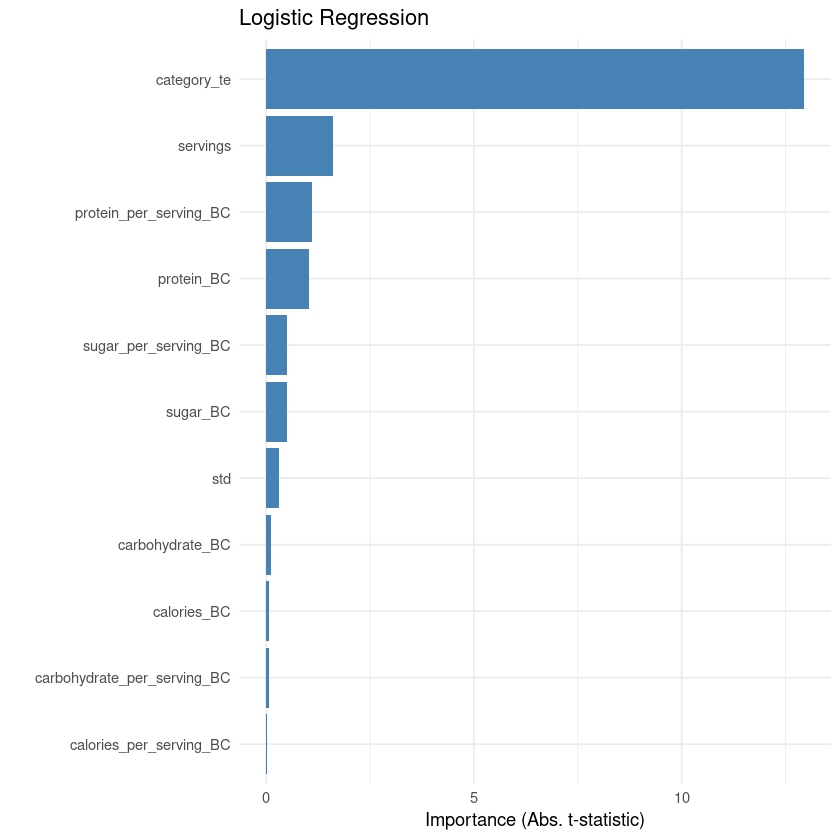

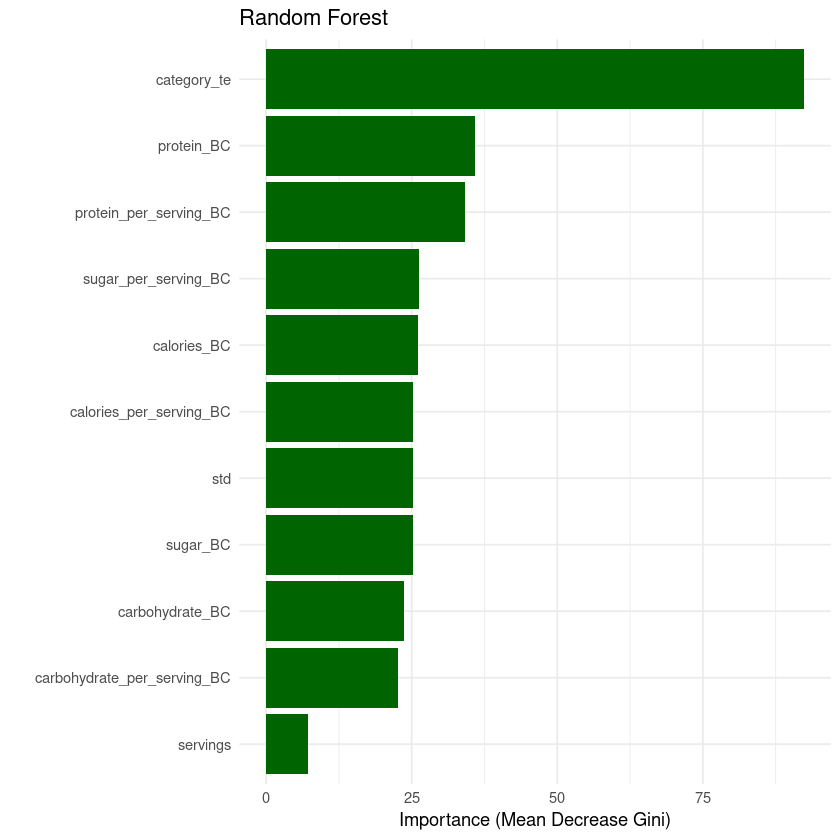

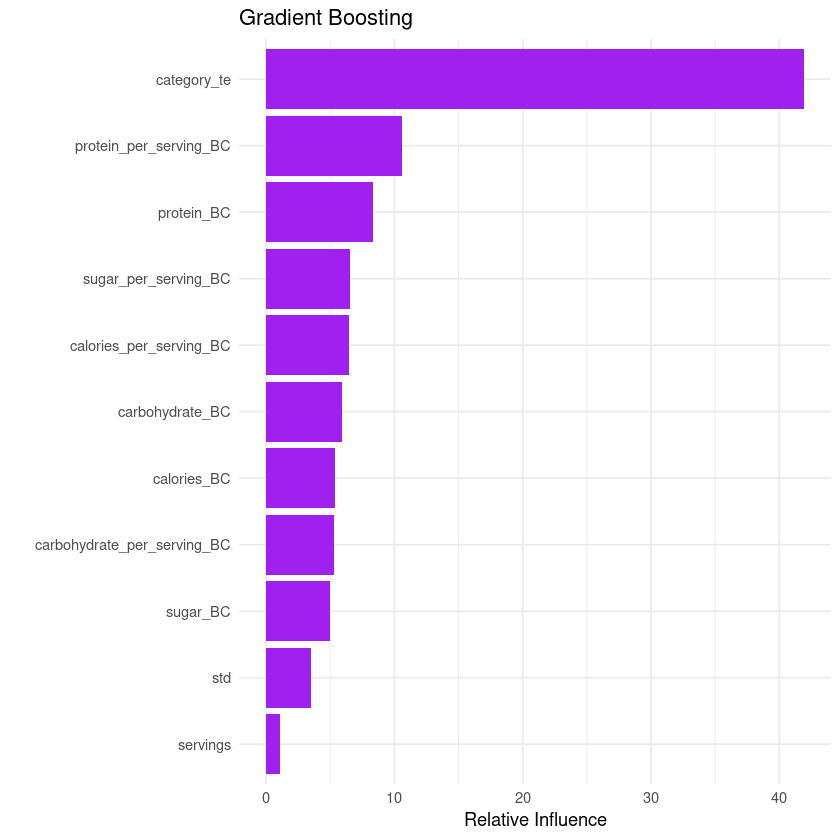

In [170]:
# Logistic Regresion_Importance
importance_log <- varImp(log_model, scale = FALSE)
importance_log_df <- data.frame(
  Variable = rownames(importance_log),
  Importance = importance_log$Overall
) %>%
  arrange(desc(Importance))

plot_log <- ggplot(importance_log_df, aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Logistic Regression", y = "Importance (Abs. t-statistic)", x = "") +
  theme_minimal()

# Random Forest Importance
importance_rf <- importance(rf_model)
importance_rf_df <- data.frame(
  Variable = rownames(importance_rf),
  Importance = importance_rf[, "MeanDecreaseGini"]
) %>%
  arrange(desc(Importance))

plot_rf <- ggplot(importance_rf_df, aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_col(fill = "darkgreen") +
  coord_flip() +
  labs(title = "Random Forest", y = "Importance (Mean Decrease Gini)", x = "") +
  theme_minimal()

# Gradient Boosting Importance
importance_gbm <- summary(gbm_model, plotit = FALSE)
importance_gbm_df <- data.frame(
  Variable = importance_gbm$var,
  Importance = importance_gbm$rel.inf
) %>%
  arrange(desc(Importance))

plot_gbm <- ggplot(importance_gbm_df, aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_col(fill = "purple") +
  coord_flip() +
  labs(title = "Gradient Boosting", y = "Relative Influence", x = "") +
  theme_minimal()

# Ploting
plot_log 
plot_rf 
plot_gbm

# 5. Buisness Metric

## 5.1 Precision KPI  

The key business metric selected for ongoing evaluation is **Precision**, with a target of at least 80%.

- Definition: Precision measures the proportion of recipes predicted as High Traffic that are truly high traffic.
- Business Relevance: High precision minimizes false positives. Misclassifying a recipe as High Traffic when it is not would lead to inefficient allocation of marketing and operational resources.
- Target: Precision ≥ 80% at the classification threshold of 0.60.
- Current Performance: All models achieved precision above 80%, with Logistic Regression at 81%, Random Forest at 82%, and Gradient Boosting at 81%.
- Strategic Implication: Maintaining precision above the target ensures that promotional efforts and resource allocation are focused on recipes with genuine high traffic potential, improving operational efficiency.

# 6. Final Summary

## 6.1 Recommendations
- **Vegetable** recipes represent a secure opportunity, with nearly 99% achieving high traffic on the site. Focus on expanding and promoting this type of recipe.
- Beverage recipes were the **least successful**, with only 5% reaching high popularity. Consider introducing new beverage concepts or redesigning existing ones to make them more appealing to the audience.
- The **Protein per Serving ratio** emerged as an important predictor. Maintaining recipes with higher protein content is likely to increase their chances of achieving high traffic.
- **Logistic Regression** proved to be the most stable method, consistently predicting recipe popularity with approximately 80% accuracy. Its balance of precision and recall makes it a reliable baseline model for future evaluations.

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation